In [18]:
import tqdm, tifffile
import numpy as np
import os, sys
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc

# Include src directory in the path dynamically
notebook_dir = os.path.abspath("")
src_path = os.path.join(notebook_dir, "../src")
sys.path.append(src_path)

from constants import MODALITY_REGISTRATION, MODALITY_PREPROCESSING


In [19]:
PATH = "/staging/leuven/stg_00077/projects/Lorenzo/FOCUS/p_PDA/d_C1"
REFERENCE_MODALITY_NAME = 'HE'
TARGET_MODALITY_NAME = 'MSI'
SAMPLE_ID = "PDAC010T0"

In [20]:
# Load the OME TIFF image from the reference
reference_image_path = MODALITY_PREPROCESSING(PATH, SAMPLE_ID, REFERENCE_MODALITY_NAME, "ome.tiff")
with tifffile.TiffFile(reference_image_path) as tif:
    reference_image = tif.asarray()

if np.argmin(reference_image.shape) == 0:
    reference_image = reference_image.transpose(1, 2, 0)  # Convert from CHW to HWC format
    reference_image = np.mean(reference_image, axis=2)  # Convert to grayscale by averaging channels

print(f"Reference image shape: {reference_image.shape}")

Reference image shape: (20202, 15614, 3)


In [21]:
# Load the registered reference modality AnnData
registered_reference_path = MODALITY_REGISTRATION(PATH, SAMPLE_ID, REFERENCE_MODALITY_NAME, "h5ad")
registered_adata = ad.read_h5ad(registered_reference_path)
print(f"Registered AnnData shape: {registered_adata.shape}")

Registered AnnData shape: (18790, 1536)


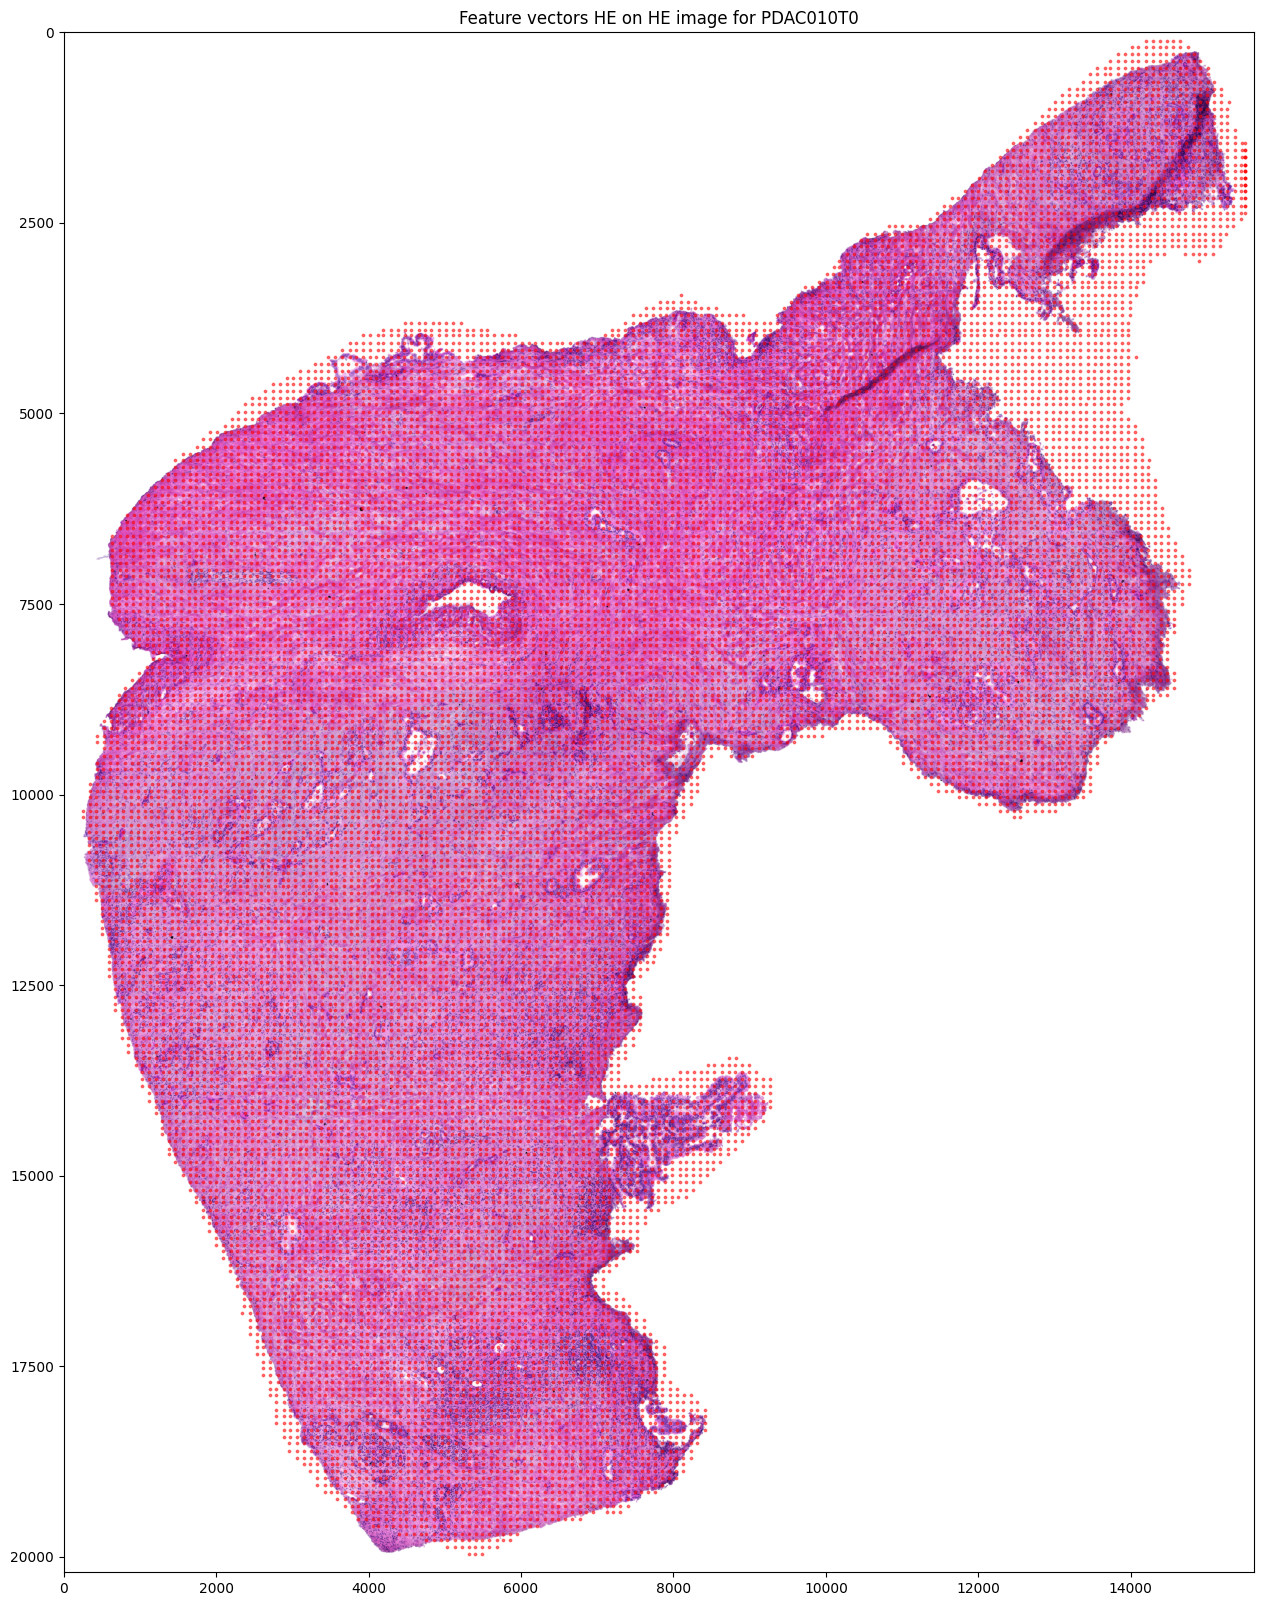

In [22]:
# Plot the reference image with overlaid target modality spatial points
plt.figure(figsize=(20, 20))
plt.imshow(reference_image, cmap='gray')
target_coords = registered_adata.obsm[f'spatial']  # Assuming spatial coordinates are stored here
plt.scatter(target_coords[:, 0], target_coords[:, 1], c='red', s=3, alpha=0.5)
plt.title(f"Feature vectors {REFERENCE_MODALITY_NAME} on {REFERENCE_MODALITY_NAME} image for {SAMPLE_ID}")
plt.show()

In [23]:
# Load the target modality AnnData
target_modality_path = MODALITY_PREPROCESSING(PATH, SAMPLE_ID, TARGET_MODALITY_NAME, "h5ad")
target_adata = ad.read_h5ad(target_modality_path)
print(f"Target AnnData shape: {target_adata.shape}")

Target AnnData shape: (18790, 24183)


In [24]:
# Visualize UMAP from both modalities
sc.pp.pca(registered_adata, n_comps=50)
sc.pp.neighbors(registered_adata)
sc.tl.umap(registered_adata)

In [25]:
# Visualize UMAP from both modalities
sc.pp.pca(target_adata, n_comps=50)
sc.pp.neighbors(target_adata)
sc.tl.umap(target_adata)

In [29]:
# Leiden clustering
sc.tl.leiden(registered_adata, resolution=0.25)
sc.tl.leiden(target_adata, resolution=0.5)

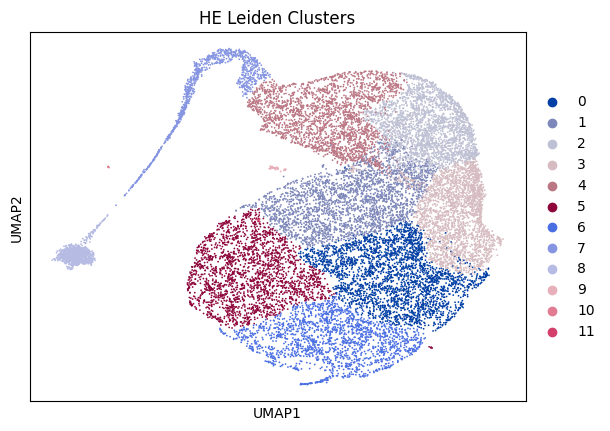

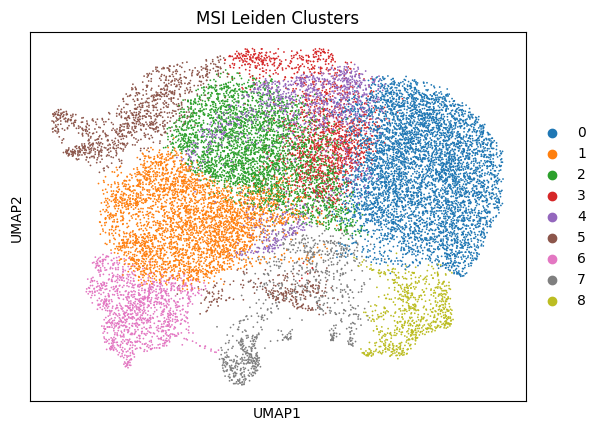

In [31]:
# Visualize UMAP
sc.pl.umap(registered_adata, color='leiden', title=f"{REFERENCE_MODALITY_NAME} Leiden Clusters")
sc.pl.umap(target_adata, color='leiden', title=f"{TARGET_MODALITY_NAME} Leiden Clusters")

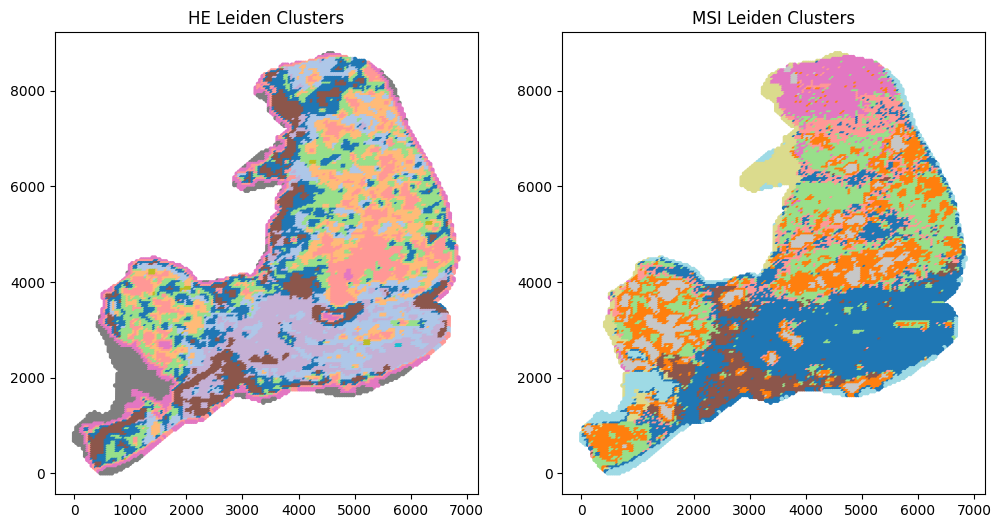

In [32]:
# Plot scatter with colors from Leiden

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(target_adata.obsm['spatial'][:, 0], target_adata.obsm['spatial'][:, 1], c=registered_adata.obs['leiden'].astype(int), cmap='tab20', s=5)
plt.title(f"{REFERENCE_MODALITY_NAME} Leiden Clusters")
plt.subplot(1, 2, 2)
plt.scatter(target_adata.obsm['spatial'][:, 0], target_adata.obsm['spatial'][:, 1], c=target_adata.obs['leiden'].astype(int), cmap='tab20', s=5)
plt.title(f"{TARGET_MODALITY_NAME} Leiden Clusters")
plt.show()  